<div style="border: 2px solid #2B5B84; padding: 20px; border-radius: 10px; background-color: #F8F9FA; text-align: center;">
    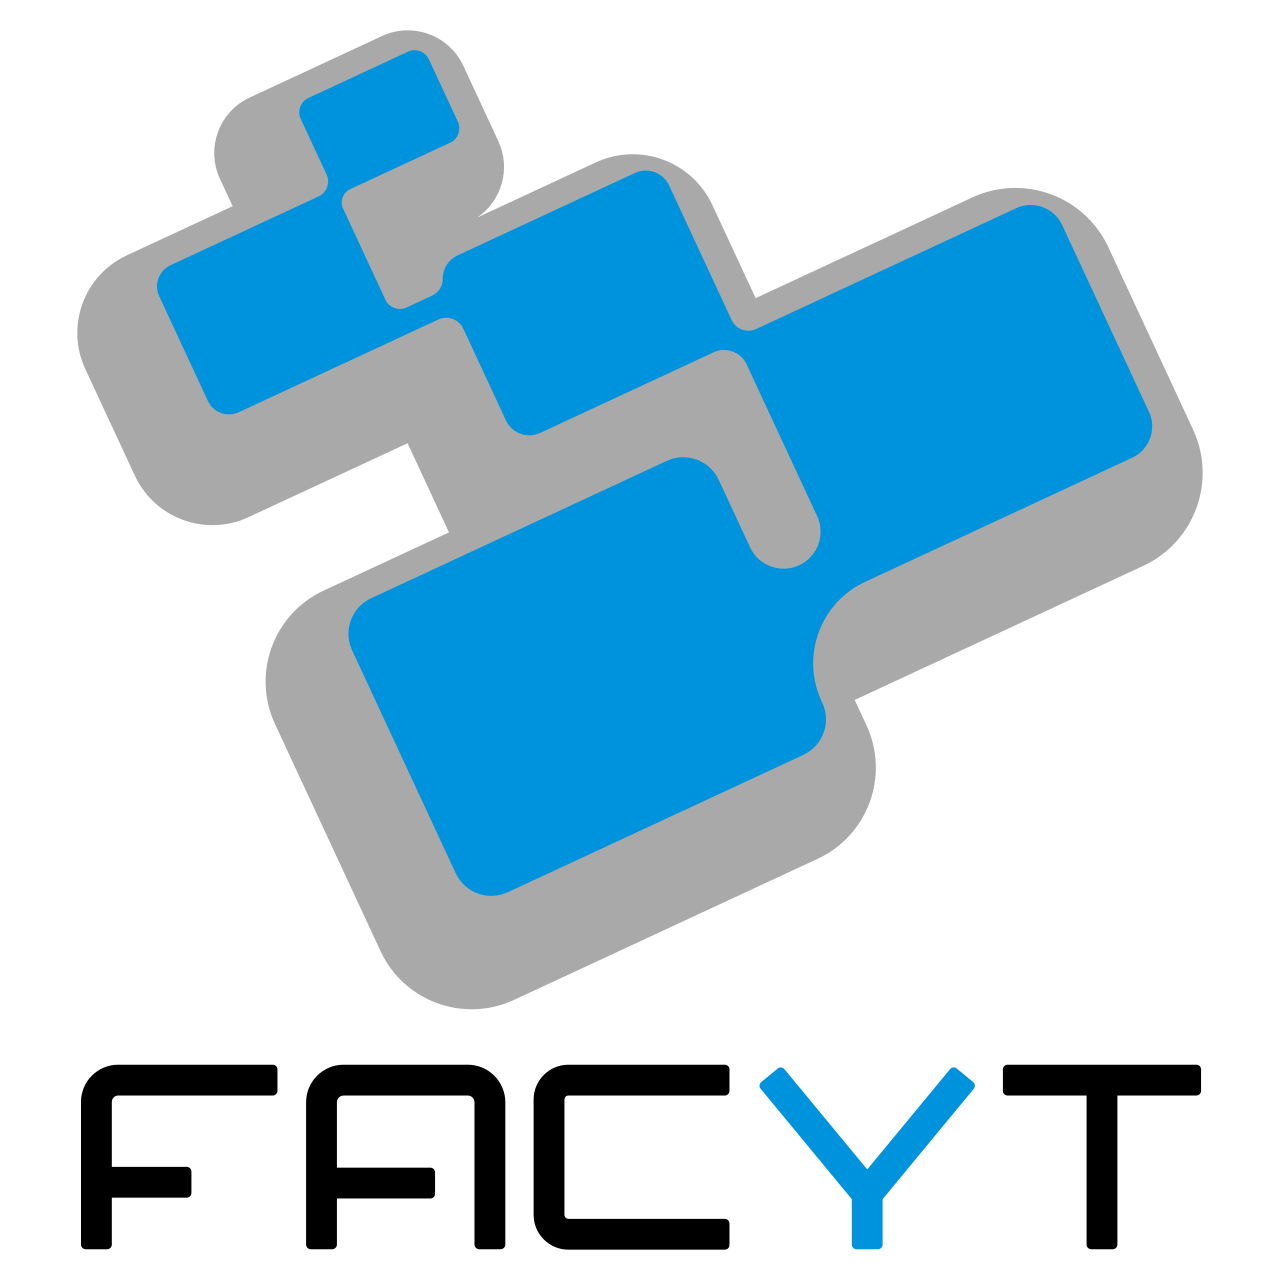
    <h2 style="color: #1B365D; margin-bottom: 2px;">UNIVERSITY OF CARABOBO</h2>
    <h3 style="color: #2B5B84; margin-top: 0px;">EXPERIMENTAL FACULTY OF SCIENCE AND TECHNOLOGY (FACYT)</h3>
    <h4 style="color: #4A777A;">DEPARTMENT OF COMPUTER SCIENCE</h4>
    <p><strong>Course:</strong> Machine Learning (Elective 2026) | <strong>Professor:</strong> Álvaro Espinoza</p>
    <hr style="border: 1px solid #2B5B84; margin: 15px 0;">
    <h1 style="color: #D9534F; margin-bottom: 5px;">Assignment 1: Exploratory Data Analysis (EDA)</h1>
    <h3 style="color: #333333;">Project: Pokémon Battle Winner Predictor</h3>
</div>

# Pokémon Battle Winner Prediction — Exploratory Data Analysis

## 1. Domain Overview and Motivation

In the Pokémon battle universe, combats are structured as turn-based duels between two contenders.
The outcome of each confrontation is governed by a combination of deterministic physical base stats
(Hit Points, Physical Attack, Physical Defense, Special Attack, Special Defense, and Speed),
elemental type matchups (damage multipliers: $2\times$, $0.5\times$, $0\times$, $1\times$), and
evolutionary tier modifiers (Mega-Evolutions, Primal Reversions, and Alternative Battle Formes).

The primary goal of this project is to build an end-to-end Machine Learning pipeline capable of
**predicting the winning Pokémon in an unobserved battle**, maximizing classification accuracy and
uncovering the fundamental dynamics that determine competitive victory.

## Unit of Observation

The fundamental **unit of observation** is a **single historical combat between two Pokémon**,
uniquely defined by:
- `First_pokemon`: identifier of the combatant entering in position 1 (first-turn candidate).
- `Second_pokemon`: identifier of the combatant entering in position 2.
- **Downstream problem type:** binary classification.
- Associated intrinsic attributes of both species (types, base stats, generation, special-form status).

## Target Variable Definition

The target variable to predict is binary:

$$\text{Target\_First\_Wins} = \begin{cases} 1, & \text{if } \text{Winner} = \text{First\_pokemon} \\ 0, & \text{if } \text{Winner} = \text{Second\_pokemon} \end{cases}$$

## Data source

The analysis is based on a **single consolidated table** built by `scripts/merge.py`:

`data/pokemon_combats_unified.csv` — 50,000 battles × 29 columns

- battle identifiers (`First_pokemon`, `Second_pokemon`) and the `Winner`;
- base stats, types, generation and Legendary flag of both fighters (`_first` / `_second` suffixes);
- binary target `Target_First_Wins`;
- engineered differential features `Speed_diff`, `Attack_diff`, `Defense_diff`.

`tests.csv` (unlabeled rows used only by the Kaggle competition) is **not used** in this project.


##  Analytical Guiding Questions

To structure our exploratory analysis, we formulate 7 core analytical questions:
1. **Data Quality and Structure:** What attributes are recorded in the datasets, what missing value mechanisms exist, and how are duplicated combats handled by the simulator?
2. **Special Forms and Evolutionary Impact:** How do Mega-Evolutions, Primal Reversions, and Alternative Battle Formes impact win rates compared to standard Pokémon?
3. **First-Turn Advantage:** Does entering in the first position (`First_pokemon`) grant an empirical advantage when speed ties occur?
4. **Speed Dominance:** What is the exact correlation and win probability when a Pokémon is strictly faster than its opponent?
5. **Relative Differentials vs Absolute Attributes:** Do relative difference variables ($\Delta\text{Speed}$, $\Delta\text{Total}$, $\Delta\text{Attack/Defense}$) provide stronger predictive power and less multicollinearity than raw absolute values?
6. **Elemental Type Matchups:** How do elemental type advantage multipliers affect battle outcomes and serve as tie-breakers in stat-parity matchups?
7. **Legendary Status and Generational Distribution:** Do Legendary Pokémon consistently dominate combat, and is there any temporal power inflation across generations?

> The observed associations describe this sample. By themselves, they do not imply causal relationships.


In [1]:
# Environment setup and reproducibility
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolve data path when running from notebooks/ or from the repo root.
DATA_DIR = Path("..") / "data"
if not (DATA_DIR / "pokemon_combats_unified.csv").exists():
    DATA_DIR = Path("data")
UNIFIED_PATH = DATA_DIR / "pokemon_combats_unified.csv"
assert UNIFIED_PATH.exists(), f"Unified dataset not found at {UNIFIED_PATH}"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

print(f"Unified dataset: {UNIFIED_PATH}")
print("Environment setup completed.")

Unified dataset: ../data/pokemon_combats_unified.csv
Environment setup completed.


In [2]:
# 1. Load the single consolidated table
df = pd.read_csv(UNIFIED_PATH)
print(f"Dimensions: {df.shape[0]:,} battles x {df.shape[1]} columns")
df.head()

Dimensions: 50,000 battles x 29 columns


,First_pokemon,Second_pokemon,Winner,Name_first,Type 1_first,Type 2_first,HP_first,Attack_first,Defense_first,Sp. Atk_first,Sp. Def_first,Speed_first,Generation_first,Legendary_first,Name_second,Type 1_second,Type 2_second,HP_second,Attack_second,Defense_second,Sp. Atk_second,Sp. Def_second,Speed_second,Generation_second,Legendary_second,Target_First_Wins,Speed_diff,Attack_diff,Defense_diff
0,266,298,298,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,Nuzleaf,Grass,Dark,70,70,40,60,40,60,3,False,0,-19,-6,10
1,702,701,701,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True,Terrakion,Rock,Fighting,91,129,90,72,90,108,5,True,0,0,-39,-18
2,191,668,668,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False,Beheeyem,Psychic,NaN,75,75,75,125,95,40,5,False,0,0,-35,10
3,237,683,683,Slugma,Fire,NaN,40,40,40,70,40,20,2,False,Druddigon,Dragon,NaN,77,120,90,60,90,48,5,False,0,-28,-80,-50
4,151,231,151,Omastar,Rock,Water,70,60,125,115,70,55,1,False,Shuckle,Bug,Rock,20,10,230,10,230,5,2,False,1,50,50,-105


## 2. Structural inspection and analytical roles

Pandas storage types (`int64`, `float64`, `bool`, `object`) do not directly correspond to
the statistical role of each variable in modeling:

| Column group | Analytical role |
|---|---|
| `First_pokemon`, `Second_pokemon`, `Winner` | Relational identifiers. Never used as numerical values; `Winner` is excluded from training to avoid leakage. |
| `Name_first`, `Name_second` | Text; used only to extract special-form indicators (Mega/Primal/Formes). |
| `Type 1_*`, `Type 2_*` | Categorical (nominal). Nulls in `Type 2` mean a monotype species. |
| `HP_*`, `Attack_*`, `Defense_*`, `Sp. Atk_*`, `Sp. Def_*`, `Speed_*` | Numerical base stats of each fighter. |
| `Generation_*` | Categorical (ordinal), treated as categorical. |
| `Legendary_*` | Binary flag. |
| `Target_First_Wins` | **Target variable** (binary). |
| `Speed_diff`, `Attack_diff`, `Defense_diff` | Engineered relative features. |


In [3]:
# Structural summary of the consolidated table
structure = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null_pct": df.isna().mean().mul(100).round(2),
    "unique": df.nunique(dropna=True),
})
structure

,dtype,non_null,null_pct,unique
First_pokemon,int64,50000,0.000,784
Second_pokemon,int64,50000,0.000,784
Winner,int64,50000,0.000,783
Name_first,str,49944,0.110,783
Type 1_first,str,50000,0.000,18
Type 2_first,str,25969,48.060,18
HP_first,int64,50000,0.000,92
Attack_first,int64,50000,0.000,111
Defense_first,int64,50000,0.000,103
Sp. Atk_first,int64,50000,0.000,104


## 3. Data quality

We audit missing values, duplicate rows, and domain validity (stat ranges, identifier range,
elemental types, target values).

In [4]:
# 3.1 Missing values
missing = df.isna().sum()
print("Missing values (consolidated table):")
print(missing[missing > 0])

# (a) Type 2 nulls -> monotype species
print(f"\nType 2 missing: {df['Type 2_first'].isna().mean()*100:.2f}% (first), "
      f"{df['Type 2_second'].isna().mean()*100:.2f}% (second) -> monotype Pokémon")

# (b) Missing names -> always the same species (id #63)
bad_ids = df.loc[df["Name_first"].isna(), "First_pokemon"].unique()
print(f"Species with missing name: {bad_ids}")

df.loc[df["Name_first"].isna(),
       ["First_pokemon", "Name_first", "Type 1_first", "HP_first", "Attack_first",
        "Defense_first", "Sp. Atk_first", "Sp. Def_first", "Speed_first"]].drop_duplicates()

Missing values (consolidated table):
Name_first          56
Type 2_first     24031
Name_second         52
Type 2_second    23985
dtype: int64

Type 2 missing: 48.06% (first), 47.97% (second) -> monotype Pokémon
Species with missing name: [63]


,First_pokemon,Name_first,Type 1_first,HP_first,Attack_first,Defense_first,Sp. Atk_first,Sp. Def_first,Speed_first
113,63,NaN,Fighting,65,105,60,60,70,95


In [5]:
# 3.2 Impute the missing species name (id #63 = Primeape)
# The stats of the unnamed species (HP 65, Attack 105, Defense 60, Sp. Atk 60,
# Sp. Def 70, Speed 95; Fighting; Gen 1) match Primeape exactly.
PRIMEAPE_STATS = {"HP": 65, "Attack": 105, "Defense": 60,
                  "Sp. Atk": 60, "Sp. Def": 70, "Speed": 95}

unnamed = df.loc[df["Name_first"].isna(),
                 ["HP_first", "Attack_first", "Defense_first", "Sp. Atk_first",
                  "Sp. Def_first", "Speed_first"]].drop_duplicates()
observed = {c: int(unnamed.iloc[0][f"{c}_first"]) for c in PRIMEAPE_STATS}
print(f"Observed stats match Primeape: {observed == PRIMEAPE_STATS}")

df["Name_first"] = df["Name_first"].fillna("Primeape")
df["Name_second"] = df["Name_second"].fillna("Primeape")
print(f"Remaining missing names: {df['Name_first'].isna().sum() + df['Name_second'].isna().sum()}")

Observed stats match Primeape: True
Remaining missing names: 0


In [6]:
# 3.3 Domain and range validation
stat_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
all_stats = [f"{c}_{s}" for c in stat_cols for s in ("first", "second")]

checks = pd.Series({
    "exact_duplicated_rows": int(df.duplicated().sum()),
    "invalid_stat_values_(<=0)": int((df[all_stats] <= 0).sum().sum()),
    "first_ids_outside_[1,800]": int((~df["First_pokemon"].between(1, 800)).sum()),
    "second_ids_outside_[1,800]": int((~df["Second_pokemon"].between(1, 800)).sum()),
    "distinct_primary_types": int(df["Type 1_first"].nunique(dropna=True)),
    "target_outside_{0,1}": int((~df["Target_First_Wins"].isin([0, 1])).sum()),
})
checks.to_frame("count")

,count
exact_duplicated_rows,1952
invalid_stat_values_(<=0),0
"first_ids_outside_[1,800]",0
"second_ids_outside_[1,800]",0
distinct_primary_types,18
"target_outside_{0,1}",0


### Data quality findings

- `Type 2` is missing for ~48% of both fighters: these are **monotype** species, so the null is
  informative, not an error.
- One species has a missing `Name` (`id #63`). Its stats match **Primeape** exactly; the name is
  imputed so text-based feature extraction works.
- 1,952 exact duplicate rows exist in `combats.csv` (3.9%); they are repeated simulator runs and
  are retained for training.
- No invalid stats, no identifiers outside `[1, 800]`, exactly 18 primary types, and the target
  takes only values `{0, 1}`.


## 4. Target variable and positional bias

We examine class proportions and establish the **naive majority baseline** that any model must
beat.

In [7]:
# 4.1 Class distribution and baseline
target_counts = df["Target_First_Wins"].value_counts().sort_index()
target_pct = df["Target_First_Wins"].value_counts(normalize=True).sort_index().mul(100)

summary_target = pd.DataFrame({
    "Class": ["0 — Second wins", "1 — First wins"],
    "Battles": [int(target_counts[0]), int(target_counts[1])],
    "Percent": target_pct.values,
})
baseline = target_pct.max()
print(f"Naive majority baseline: {baseline:.2f}%")
summary_target

Naive majority baseline: 52.80%


,Class,Battles,Percent
0,0 — Second wins,26399,52.798
1,1 — First wins,23601,47.202


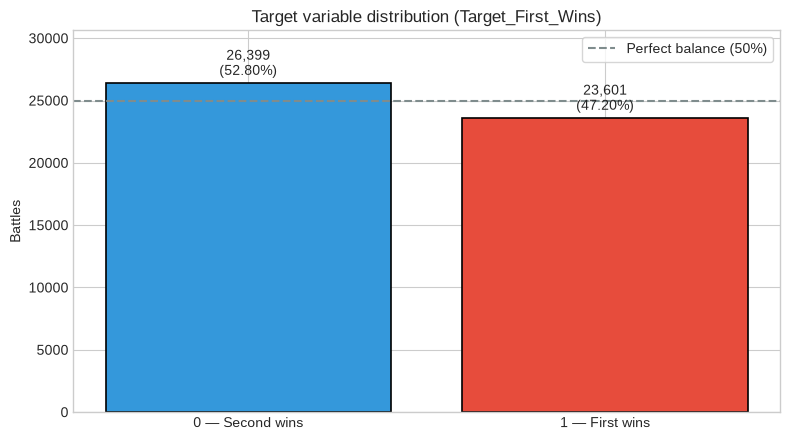

In [8]:
# 4.2 Visualization
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(summary_target["Class"], summary_target["Battles"],
              color=["#3498DB", "#E74C3C"], edgecolor="black", linewidth=1.2)
max_battles = int(summary_target["Battles"].max())
ax.bar_label(bars, labels=[f"{b:,}\n({p:.2f}%)" for b, p in zip(summary_target["Battles"], summary_target["Percent"])],
             padding=3, fontsize=10)
ax.axhline(len(df) / 2, color="#7F8C8D", linestyle="--", label="Perfect balance (50%)")
ax.set(title="Target variable distribution (Target_First_Wins)", ylabel="Battles",
       ylim=(0, max_battles * 1.16))
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

### Target findings

- The target is nearly balanced, but **not** perfectly: the second fighter wins `52.80%` and the
  first `47.20%`. This is a **systematic positional bias of +5.6 pp** favoring `Second_pokemon`,
  not a "balanced" dataset.
- The naive majority baseline is **52.80%** — the absolute performance floor for any classifier.


## 5. Order of the fighters, speed, and simulator determinism

This turn-based simulator must decide who attacks first. We test the two candidate rules
(a) the faster Pokémon attacks first; (b) on a speed tie, one of the positions gets initiative.

In [9]:
# 5.1 Outcome by speed condition
df["Speed_diff"] = df["Speed_first"] - df["Speed_second"]
conditions = {
    "First faster (ΔSpeed > 0)": df["Speed_diff"] > 0,
    "Speed tie (ΔSpeed = 0)": df["Speed_diff"] == 0,
    "First slower (ΔSpeed < 0)": df["Speed_diff"] < 0,
}
rows = []
for label, mask in conditions.items():
    rows.append({"Condition": label,
                 "Battles": int(mask.sum()),
                 "First win rate (%)": round(df.loc[mask, "Target_First_Wins"].mean() * 100, 2)})
speed_summary = pd.DataFrame(rows)
display(speed_summary)

tie = df["Speed_diff"].eq(0)
print(f"Speed ties: {tie.sum():,} battles ({tie.mean()*100:.2f}%)")
print(f"Second_pokemon wins every speed tie: {(df.loc[tie, 'Winner'] == df.loc[tie, 'Second_pokemon']).all()}")

,Condition,Battles,First win rate (%)
0,First faster (ΔSpeed > 0),24334,92.390
1,Speed tie (ΔSpeed = 0),1328,0.000
2,First slower (ΔSpeed < 0),24338,4.600


Speed ties: 1,328 battles (2.66%)
Second_pokemon wins every speed tie: True


In [10]:
# 5.2 Determinism across orientation-swapped pairs
oriented = set(zip(df["First_pokemon"], df["Second_pokemon"]))
rematched = sorted({tuple(sorted(p)) for p in oriented if (p[1], p[0]) in oriented})  # fought both ways

df["pair"] = df[["First_pokemon", "Second_pokemon"]].apply(lambda r: tuple(sorted(r)), axis=1)
pair_winners = df.groupby("pair")["Winner"].nunique()
det = sum(1 for k in rematched if pair_winners[k] == 1)
var = sum(1 for k in rematched if pair_winners[k] > 1)
print(f"Pairs fought in both orientations: {len(rematched):,}")
print(f"  - Same absolute winner regardless of order: {det:,} ({det/len(rematched)*100:.1f}%)")
print(f"  - Winner flips when order is swapped:       {var:,} ({var/len(rematched)*100:.1f}%)")

var_pairs = set(k for k in rematched if pair_winners[k] > 1)
var_df = df[df["pair"].isin(var_pairs)].drop_duplicates("pair")
print(f"  - Of the variable pairs, speed ties account for: {var_df['Speed_diff'].eq(0).mean()*100:.1f}%")

Pairs fought in both orientations: 1,822
  - Same absolute winner regardless of order: 1,712 (94.0%)
  - Winner flips when order is swapped:       110 (6.0%)
  - Of the variable pairs, speed ties account for: 43.6%


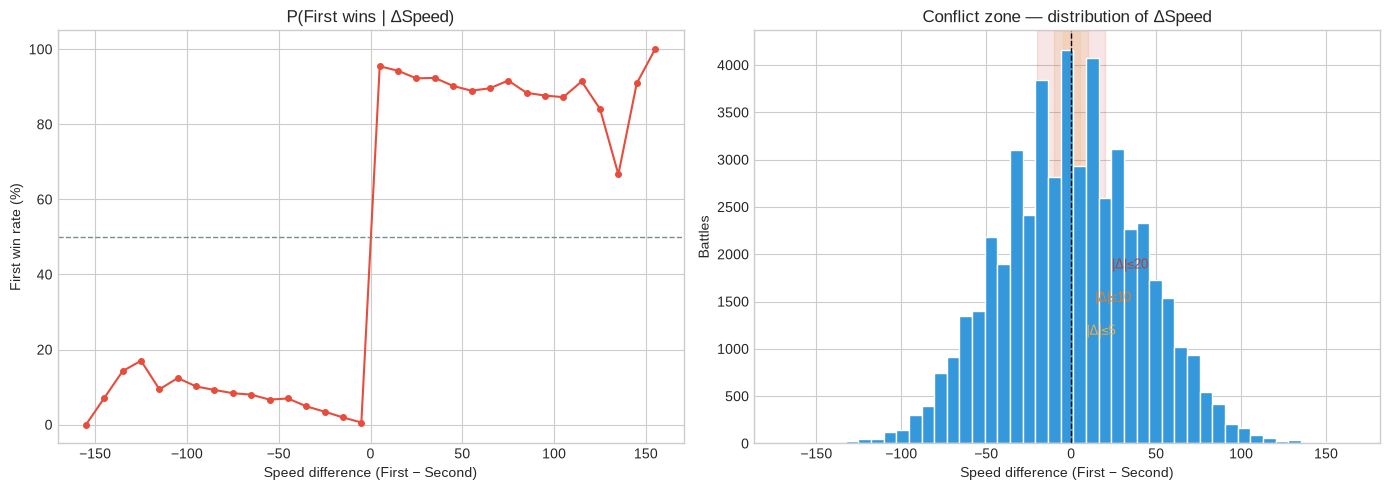

|ΔSpeed| <=  0: 1,328 battles (2.66%) — First win rate 0.00%
|ΔSpeed| <=  5: 5,974 battles (11.95%) — First win rate 37.55%
|ΔSpeed| <= 10: 10,729 battles (21.46%) — First win rate 42.87%
|ΔSpeed| <= 20: 19,451 battles (38.90%) — First win rate 45.27%


In [11]:
# 5.3 Calibrated win probability vs speed difference (A1) + conflict zone (A5)
bins = np.arange(-160, 161, 10)
df["ds_bin"] = pd.cut(df["Speed_diff"], bins=bins)
agg = df.groupby("ds_bin", observed=True)["Target_First_Wins"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

centers = [iv.mid for iv in agg.index]
ax1.plot(centers, agg.values * 100, marker="o", color="#E74C3C", ms=4, lw=1.5)
ax1.axhline(50, color="#7F8C8D", linestyle="--", lw=1)
ax1.set(title="P(First wins | ΔSpeed)", xlabel="Speed difference (First − Second)",
        ylabel="First win rate (%)", ylim=(-5, 105))

for th, color in [(5, "#F5B041"), (10, "#E67E22"), (20, "#C0392B")]:
    ax2.axvspan(-th, th, alpha=0.12, color=color)
    ax2.text(th + 4, 1150 + 350 * (th // 10), f"|Δ|≤{th}", fontsize=9, color=color)
df["Speed_diff"].hist(bins=45, ax=ax2, color="#3498DB", edgecolor="white")
ax2.axvline(0, color="black", linestyle="--", lw=1)
ax2.set(title="Conflict zone — distribution of ΔSpeed", xlabel="Speed difference (First − Second)",
        ylabel="Battles")
plt.tight_layout()
plt.show()

for th in (0, 5, 10, 20):
    m = df["Speed_diff"].abs().le(th)
    print(f"|ΔSpeed| <= {th:>2}: {m.sum():,} battles ({m.mean()*100:.2f}%) "
          f"— First win rate {df.loc[m,'Target_First_Wins'].mean()*100:.2f}%")

### Speed and order findings

1. **The faster Pokémon attacks first and wins ~92–95% of battles**, regardless of position:
   - First faster: First wins **92.39%**; First slower: First wins **4.60%**.
2. **On a speed tie the SECOND fighter wins 100% of the time** (1,328 battles). The initiative
   in a tie goes to `Second_pokemon`. This corrects the previous version of this notebook, which
   claimed the tie-break favored the first fighter.
3. **Order matters only in speed ties.** Global positional bias (+5.6 pp for Second) is entirely
   explained by the tie rule together with the 2.66% of ties.
4. **Determinism:** 94.0% of orientation-swapped pairs give the same absolute winner; in the 6.0%
   that flip, speed ties explain 43.6% — the remaining 56.4% are **not explained by speed** and are
   left as irreducible variance of the simulator.
5. **The conflict zone is small and sharp:** 11.9% of battles have |ΔSpeed| ≤ 5 (win rate 37.6%),
   and beyond |ΔSpeed| > 20 the outcome is nearly certain.


## 6. Attribute differentials as predictors

We compute relative differences (First − Second) for every base stat and total power, and measure
their linear relationship with the target.

In [12]:
# 6.1 Differentials and correlation with the target
stat_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
for c in stat_cols:
    df[f"{c}_diff"] = df[f"{c}_first"] - df[f"{c}_second"]
df["Total_first"] = df[[f"{c}_first" for c in stat_cols]].sum(axis=1)
df["Total_second"] = df[[f"{c}_second" for c in stat_cols]].sum(axis=1)
df["Total_diff"] = df["Total_first"] - df["Total_second"]

delta_cols = ["HP_diff", "Attack_diff", "Defense_diff", "Sp. Atk_diff",
              "Sp. Def_diff", "Speed_diff", "Total_diff"]
corr_target = df[delta_cols + ["Target_First_Wins"]].corr()["Target_First_Wins"].drop("Target_First_Wins")
corr_target.sort_values(ascending=False).to_frame("r (target)")

,r (target)
Speed_diff,0.678
Total_diff,0.470
Attack_diff,0.362
Sp. Atk_diff,0.349
Sp. Def_diff,0.219
HP_diff,0.194
Defense_diff,0.079


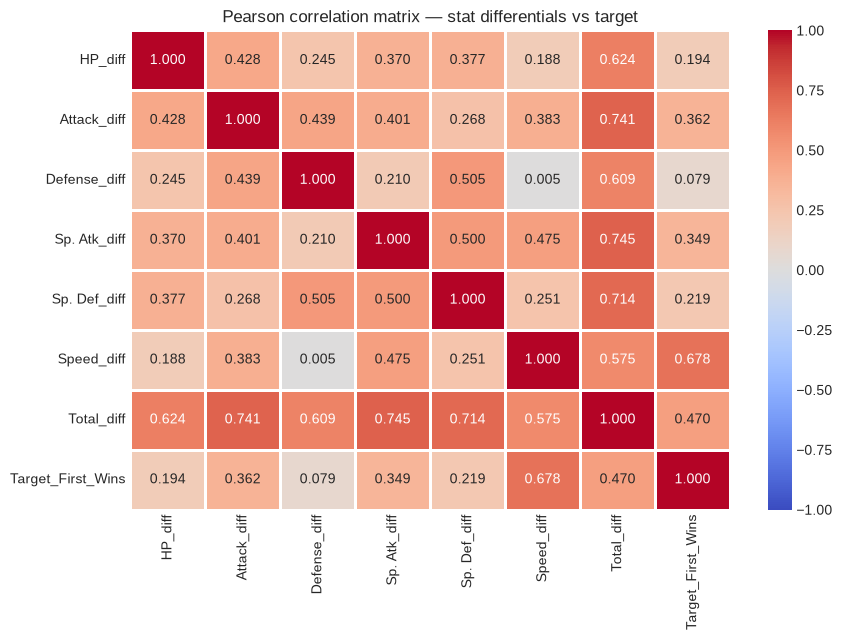

In [13]:
# 6.2 Correlation matrix (multicollinearity diagnostic)
corr_mat = df[delta_cols + ["Target_First_Wins"]].corr()

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(corr_mat, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.8, linecolor="white", ax=ax)
ax.set(title="Pearson correlation matrix — stat differentials vs target")
plt.tight_layout()
plt.show()

### Predictor findings

- **Speed difference is the strongest linear predictor** ($r = +0.678$), followed by total power
  ($r = +0.470$) and physical Attack ($r = +0.362$); passive Defense is nearly irrelevant
  ($r = +0.079$). This is a correlation ranking, not a causal "influence" claim.
- **Multicollinearity:** `Total_diff` is strongly redundant with `Attack_diff` ($r\approx 0.74$),
  while `Speed_diff` and `Defense_diff` are almost orthogonal ($r\approx 0.005$). Prefer the
  differentials over the 12 raw stats to keep the feature space compact and decorrelated.


## 7. Elemental type effectiveness

Pokémon types apply damage multipliers (super effective ×2, not very effective ×0.5, immune ×0,
neutral ×1). We quantify how type advantage affects the outcome.

In [14]:
# 7.1 Type effectiveness chart (single definition, reused later)
type_chart = {
    ('Normal', 'Rock'): 0.5, ('Normal', 'Ghost'): 0.0, ('Normal', 'Steel'): 0.5,
    ('Fire', 'Fire'): 0.5, ('Fire', 'Water'): 0.5, ('Fire', 'Grass'): 2.0, ('Fire', 'Ice'): 2.0,
    ('Fire', 'Bug'): 2.0, ('Fire', 'Rock'): 0.5, ('Fire', 'Dragon'): 0.5, ('Fire', 'Steel'): 2.0,
    ('Water', 'Fire'): 2.0, ('Water', 'Water'): 0.5, ('Water', 'Grass'): 0.5, ('Water', 'Ground'): 2.0,
    ('Water', 'Rock'): 2.0, ('Water', 'Dragon'): 0.5,
    ('Electric', 'Water'): 2.0, ('Electric', 'Electric'): 0.5, ('Electric', 'Grass'): 0.5,
    ('Electric', 'Ground'): 0.0, ('Electric', 'Flying'): 2.0, ('Electric', 'Dragon'): 0.5,
    ('Grass', 'Fire'): 0.5, ('Grass', 'Water'): 2.0, ('Grass', 'Grass'): 0.5, ('Grass', 'Poison'): 0.5,
    ('Grass', 'Ground'): 2.0, ('Grass', 'Flying'): 0.5, ('Grass', 'Bug'): 0.5, ('Grass', 'Rock'): 2.0,
    ('Grass', 'Dragon'): 0.5, ('Grass', 'Steel'): 0.5,
    ('Ice', 'Fire'): 0.5, ('Ice', 'Water'): 0.5, ('Ice', 'Grass'): 2.0, ('Ice', 'Ice'): 0.5,
    ('Ice', 'Ground'): 2.0, ('Ice', 'Flying'): 2.0, ('Ice', 'Dragon'): 2.0, ('Ice', 'Steel'): 0.5,
    ('Fighting', 'Normal'): 2.0, ('Fighting', 'Ice'): 2.0, ('Fighting', 'Poison'): 0.5,
    ('Fighting', 'Flying'): 0.5, ('Fighting', 'Psychic'): 0.5, ('Fighting', 'Bug'): 0.5,
    ('Fighting', 'Rock'): 2.0, ('Fighting', 'Ghost'): 0.0, ('Fighting', 'Dark'): 2.0,
    ('Fighting', 'Steel'): 2.0, ('Fighting', 'Fairy'): 0.5,
    ('Poison', 'Grass'): 2.0, ('Poison', 'Poison'): 0.5, ('Poison', 'Ground'): 0.5,
    ('Poison', 'Rock'): 0.5, ('Poison', 'Ghost'): 0.5, ('Poison', 'Steel'): 0.0, ('Poison', 'Fairy'): 2.0,
    ('Ground', 'Fire'): 2.0, ('Ground', 'Electric'): 2.0, ('Ground', 'Grass'): 0.5,
    ('Ground', 'Poison'): 2.0, ('Ground', 'Flying'): 0.0, ('Ground', 'Bug'): 0.5,
    ('Ground', 'Rock'): 2.0, ('Ground', 'Steel'): 2.0,
    ('Flying', 'Electric'): 0.5, ('Flying', 'Grass'): 2.0, ('Flying', 'Fighting'): 2.0,
    ('Flying', 'Bug'): 2.0, ('Flying', 'Rock'): 0.5, ('Flying', 'Steel'): 0.5,
    ('Psychic', 'Fighting'): 2.0, ('Psychic', 'Poison'): 2.0, ('Psychic', 'Psychic'): 0.5,
    ('Psychic', 'Dark'): 0.0, ('Psychic', 'Steel'): 0.5,
    ('Bug', 'Fire'): 0.5, ('Bug', 'Grass'): 2.0, ('Bug', 'Fighting'): 0.5, ('Bug', 'Poison'): 0.5,
    ('Bug', 'Flying'): 0.5, ('Bug', 'Psychic'): 2.0, ('Bug', 'Ghost'): 0.5, ('Bug', 'Dark'): 2.0,
    ('Bug', 'Steel'): 0.5, ('Bug', 'Fairy'): 0.5,
    ('Rock', 'Fire'): 2.0, ('Rock', 'Ice'): 2.0, ('Rock', 'Fighting'): 0.5, ('Rock', 'Ground'): 0.5,
    ('Rock', 'Flying'): 2.0, ('Rock', 'Bug'): 2.0, ('Rock', 'Steel'): 0.5,
    ('Ghost', 'Normal'): 0.0, ('Ghost', 'Psychic'): 2.0, ('Ghost', 'Ghost'): 2.0, ('Ghost', 'Dark'): 0.5,
    ('Dragon', 'Dragon'): 2.0, ('Dragon', 'Steel'): 0.5, ('Dragon', 'Fairy'): 0.0,
    ('Dark', 'Fighting'): 0.5, ('Dark', 'Psychic'): 2.0, ('Dark', 'Ghost'): 2.0,
    ('Dark', 'Dark'): 0.5, ('Dark', 'Fairy'): 0.5,
    ('Steel', 'Fire'): 0.5, ('Steel', 'Water'): 0.5, ('Steel', 'Electric'): 0.5, ('Steel', 'Ice'): 2.0,
    ('Steel', 'Rock'): 2.0, ('Steel', 'Steel'): 0.5, ('Steel', 'Fairy'): 2.0,
    ('Fairy', 'Fire'): 0.5, ('Fairy', 'Fighting'): 2.0, ('Fairy', 'Poison'): 0.5,
    ('Fairy', 'Dragon'): 2.0, ('Fairy', 'Dark'): 2.0, ('Fairy', 'Steel'): 0.5,
}

def calculate_type_multiplier(atk_t1, atk_t2, def_t1, def_t2):
    def val(a, d):
        if not isinstance(a, str) or not isinstance(d, str):
            return 1.0
        return type_chart.get((a, d), 1.0)
    m1 = val(atk_t1, def_t1) * val(atk_t1, def_t2)
    m2 = val(atk_t2, def_t1) * val(atk_t2, def_t2) if isinstance(atk_t2, str) else 1.0
    return max(m1, m2)

print(f"Type chart ready: {len(type_chart)} known matchups (Gen 6 standard).")

Type chart ready: 120 known matchups (Gen 6 standard).


                      count  mean  First win rate (%)
type_adv                                             
Advantage (First)     11040 0.528              52.770
Neutral               27697 0.471              47.080
Disadvantage (First)  11263 0.420              42.050


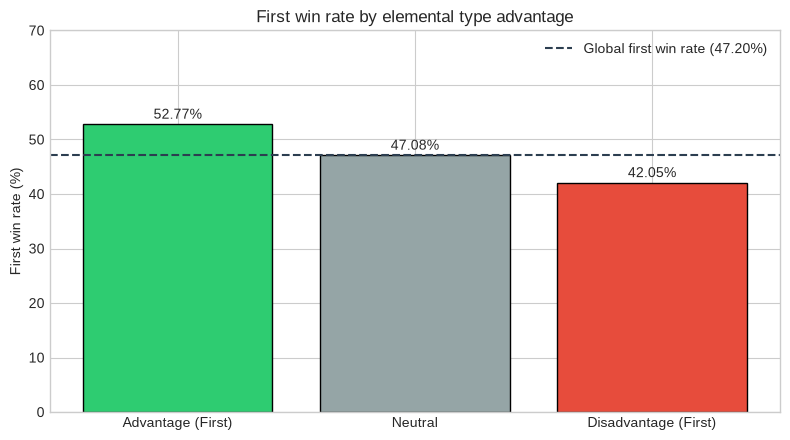

In [15]:
# 7.2 Effectiveness per battle and advantage effect
df["Eff_1v2"] = df.apply(lambda r: calculate_type_multiplier(
    r["Type 1_first"], r["Type 2_first"], r["Type 1_second"], r["Type 2_second"]), axis=1)
df["Eff_2v1"] = df.apply(lambda r: calculate_type_multiplier(
    r["Type 1_second"], r["Type 2_second"], r["Type 1_first"], r["Type 2_first"]), axis=1)
df["type_adv"] = np.select(
    [df["Eff_1v2"] > df["Eff_2v1"], df["Eff_1v2"] < df["Eff_2v1"]],
    ["Advantage (First)", "Disadvantage (First)"], default="Neutral")

ta = df.groupby("type_adv")["Target_First_Wins"].agg(["count", "mean"])
ta["First win rate (%)"] = (ta["mean"] * 100).round(2)
ta = ta.reindex(["Advantage (First)", "Neutral", "Disadvantage (First)"])
print(ta)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(ta.index, ta["First win rate (%)"], color=["#2ECC71", "#95A5A6", "#E74C3C"], edgecolor="black")
ax.bar_label(bars, fmt="%.2f%%", padding=2)
ax.axhline(47.20, color="#2C3E50", linestyle="--", label="Global first win rate (47.20%)")
ax.set(title="First win rate by elemental type advantage", ylabel="First win rate (%)", ylim=(0, 70))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

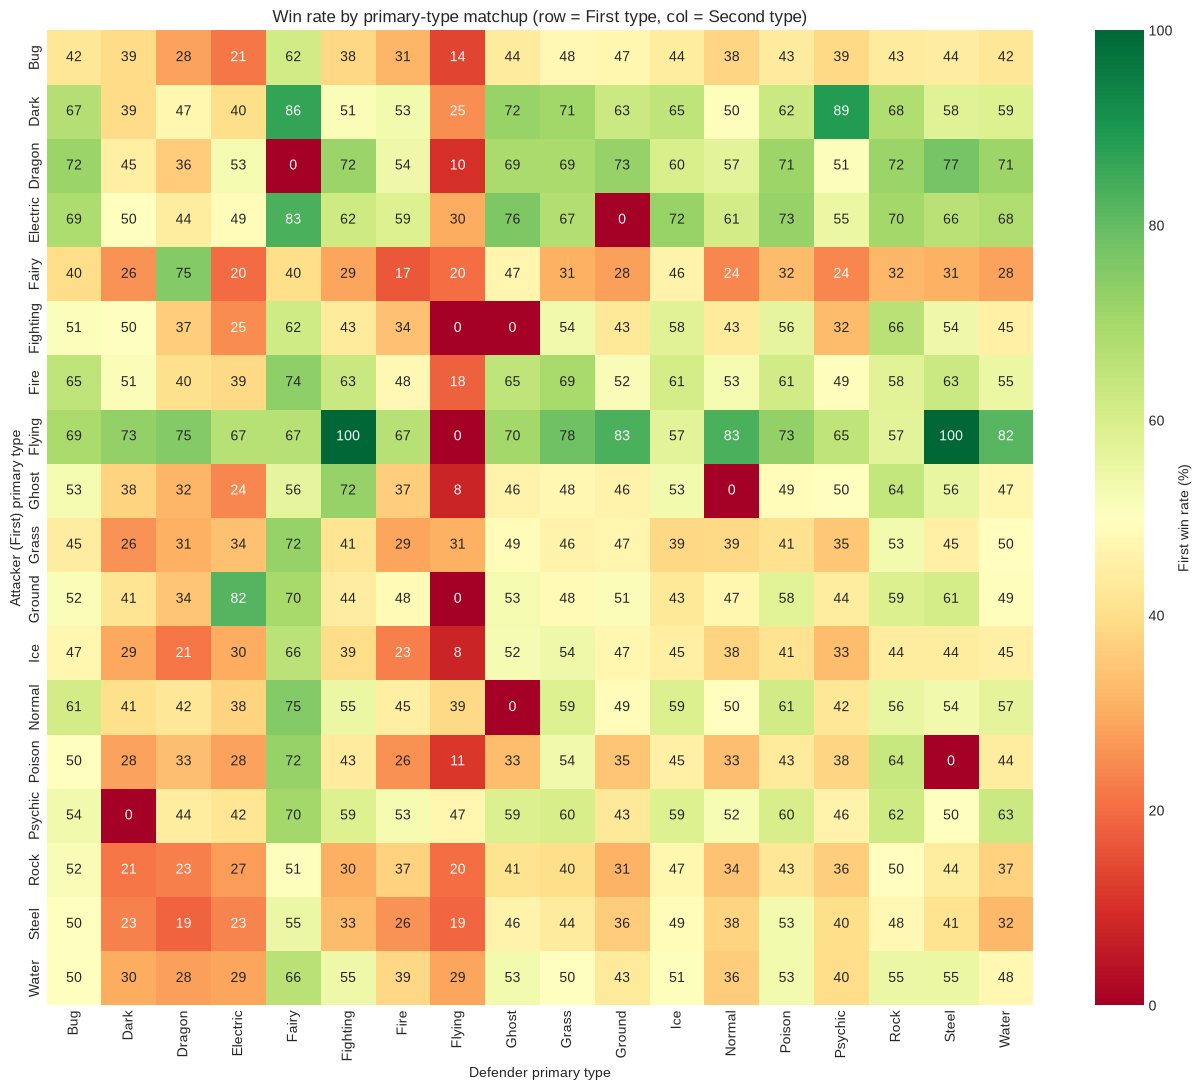

In [16]:
# 7.3 Win-rate heatmap by primary-type matchup (A4)
matchup = df.pivot_table(index="Type 1_first", columns="Type 1_second",
                         values="Target_First_Wins", aggfunc="mean") * 100
matchup = matchup.reindex(index=sorted(matchup.index), columns=sorted(matchup.columns))

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(matchup, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100,
            cbar_kws={"label": "First win rate (%)"}, ax=ax)
ax.set(title="Win rate by primary-type matchup (row = First type, col = Second type)",
       xlabel="Defender primary type", ylabel="Attacker (First) primary type")
plt.tight_layout()
plt.show()

### Type findings

- Type advantage gives the first fighter **~+10 pp** of win rate (52.8% with advantage vs 42.0% with
  disadvantage), acting as a tie-breaker in otherwise parity duels.
- The matchup heatmap shows most cells near 50% (Speed dominates), with pronounced imbalances only
  in a few matchups (e.g., Fire vs Grass, Ground vs Electric). Cells are averaged over primary
  types only; sparse cells should be read with caution.


## 8. Special forms (Mega, Primal, Legendary, Alt. Forms)

We classify every species into a single, consistent taxonomy. Special forms have inflated base
stats and are expected to dominate standard Pokémon.

In [17]:
# 8.1 Unified form classification
def classify_form(name, legendary):
    n = str(name)
    if "Mega " in n:
        return "Mega-Evolution"
    if "Primal " in n:
        return "Primal Reversion"
    if any(f in n for f in ["Forme", "Mode", "Unbound", "Black Kyurem", "White Kyurem", "Rotom"]):
        return "Alt. Combat Form"
    if any(v in n for v in ["Size", "Cloak", "Male", "Female"]):
        return "Variant"
    if legendary:
        return "Legendary"
    return "Standard"

df["form_first"] = df.apply(lambda r: classify_form(r["Name_first"], r["Legendary_first"]), axis=1)
df["form_second"] = df.apply(lambda r: classify_form(r["Name_second"], r["Legendary_second"]), axis=1)

species = df[["Name_first", "form_first"]].drop_duplicates("Name_first")
species["form_first"].value_counts().to_frame("species").assign(
    pct=lambda x: (x["species"] / len(species) * 100).round(1))

,species,pct
form_first,,
Standard,652,83.200
Mega-Evolution,47,6.000
Legendary,39,5.000
Alt. Combat Form,32,4.100
Variant,12,1.500
Primal Reversion,2,0.300


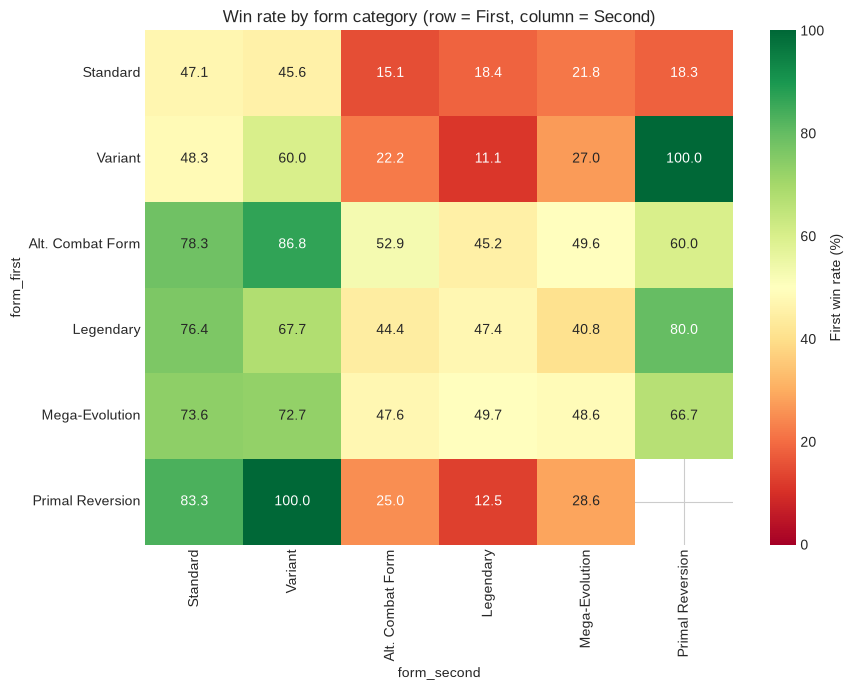

In [18]:
# 8.2 Cross-permutation win-rate heatmap
order = ["Standard", "Variant", "Alt. Combat Form", "Legendary", "Mega-Evolution", "Primal Reversion"]
hm = pd.crosstab(df["form_first"], df["form_second"], values=df["Target_First_Wins"], aggfunc="mean") \
    .reindex(index=order, columns=order) * 100

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(hm, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100,
            cbar_kws={"label": "First win rate (%)"}, ax=ax)
ax.set(title="Win rate by form category (row = First, column = Second)")
plt.tight_layout()
plt.show()

### Special-form findings

- 132 of the 784 species that appear in battles are special forms: 47 Mega, 39 Legendary,
  32 Alt. Combat Form, 12 size/gender Variants, and 2 Primal.
- Special forms dominate standard Pokémon: Mega 73.6%, Primal 83.3%, Legendary 76.4%,
  Alt. Combat Form 78.3% vs Standard.
- Mirror matches between special forms balance near 50% (48.97%), so the advantage is **stat gap**,
  not category per se.


## 9. Battle frequency and individual dominance per species

We inspect how often each species fights and how often it wins, to expose usage imbalances and
individual standouts in the combat pool.

In [19]:
# 9.1 Per-species usage and win rate
freq = pd.concat([df["First_pokemon"], df["Second_pokemon"]]).value_counts().rename("n_battles")
wins = df.groupby("Winner").size().rename("n_wins")
per = pd.DataFrame({"n_battles": freq, "n_wins": wins}).fillna(0)
per["win_rate"] = per["n_wins"] / per["n_battles"] * 100

meta = df[["First_pokemon", "Name_first", "form_first", "Legendary_first", "Total_first"]].drop_duplicates("First_pokemon").set_index("First_pokemon")
per = per.join(meta).reset_index().rename(columns={"index": "First_pokemon"})
per = per.sort_values("n_battles", ascending=False)
print(f"Species appearing in battles: {len(per)}  (catalogue: 800)")
per[["First_pokemon", "Name_first", "n_battles", "n_wins", "win_rate", "Total_first", "form_first"]].head(10)

Species appearing in battles: 784  (catalogue: 800)


,First_pokemon,Name_first,n_battles,n_wins,win_rate,Total_first,form_first
155,163,Mewtwo,164,152.000,92.683,680,Legendary
333,344,Illumise,160,104.000,65.000,400,Standard
651,667,Elgyem,159,21.000,13.208,335,Standard
205,214,Murkrow,158,130.000,82.278,405,Standard
742,758,Malamar,158,108.000,68.354,482,Standard
73,79,Tentacool,157,79.000,50.318,335,Standard
674,690,Braviary,156,108.000,69.231,510,Standard
746,762,Dragalge,156,31.000,19.872,494,Standard
363,374,Corphish,155,22.000,14.194,308,Standard
458,470,Shellos,154,18.000,11.688,325,Standard


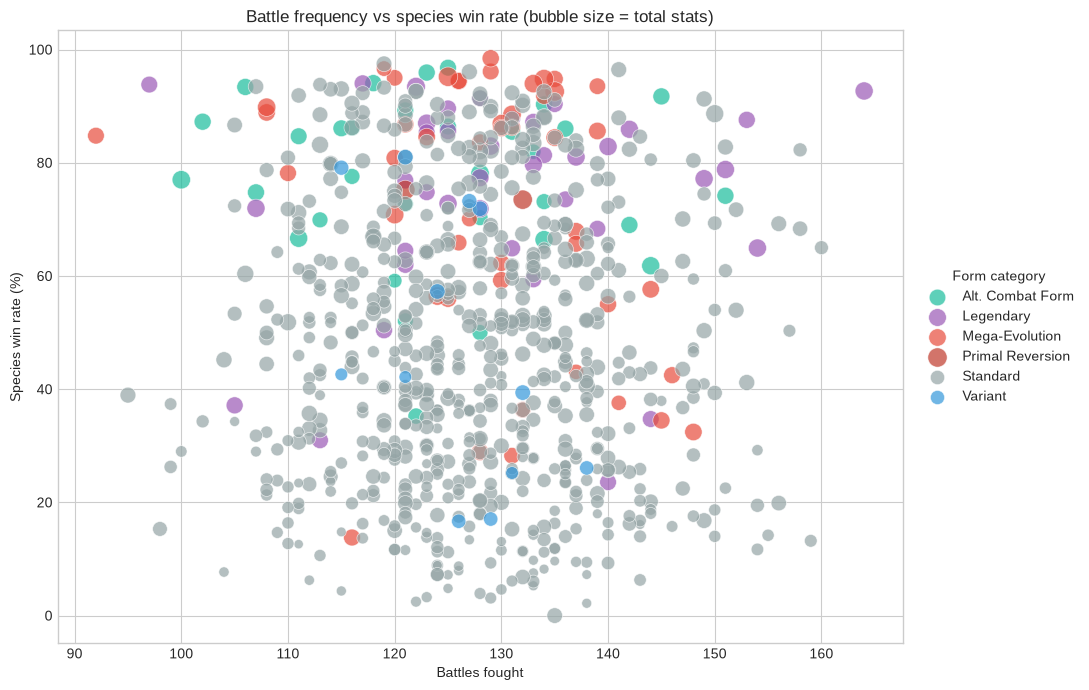

Most dominant species:
            Name_first  n_battles  win_rate  Total_first
       Mega Aerodactyl        129    98.450          615
               Weavile        119    97.479          510
Tornadus Therian Forme        125    96.800          580
         Mega Beedrill        119    96.639          495
            Aerodactyl        141    96.454          515

Weaker species (never or rarely winning):
Name_first  n_battles  win_rate
   Shuckle        135     0.000
   Silcoon        138     2.174
    Togepi        122     2.459
   Solosis        129     3.101
    Slugma        123     3.252


In [20]:
# 9.2 Bubble chart: usage vs win rate (size = total stats)
palette = {"Standard": "#95A5A6", "Variant": "#3498DB", "Alt. Combat Form": "#1ABC9C",
           "Legendary": "#9B59B6", "Mega-Evolution": "#E74C3C", "Primal Reversion": "#C0392B"}

fig, ax = plt.subplots(figsize=(11, 7))
for cat, grp in per.groupby("form_first"):
    ax.scatter(grp["n_battles"], grp["win_rate"], s=grp["Total_first"] / 4, alpha=0.7,
               label=cat, color=palette[cat], edgecolor="white", linewidth=0.5)
ax.set(title="Battle frequency vs species win rate (bubble size = total stats)",
       xlabel="Battles fought", ylabel="Species win rate (%)")
ax.legend(title="Form category", loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

print("Most dominant species:")
print(per.sort_values("win_rate", ascending=False)[["Name_first", "n_battles", "win_rate", "Total_first"]].head(5).to_string(index=False))
print("\nWeaker species (never or rarely winning):")
print(per.sort_values("win_rate")[["Name_first", "n_battles", "win_rate"]].head(5).to_string(index=False))

### Frequency findings

- Battles are fairly evenly distributed across species (92 to 164 battles each); usage frequency
  is not strongly correlated with power.
- A few species dominate (e.g., win rate 92.7% over 164 battles) while others barely win (win rate
  13.2% over 159 battles), so **species identity encodes information** — but it must be expressed
  through stats/forms, never through raw IDs (overfitting / leakage).


## 10. Exploratory feature engineering

We consolidate the EDA findings into five master features, each grounded in combat mechanics:

1. **`Speed_diff`** — turn-order initiative (already in the consolidated table).
2. **`Stat_Total_Diff`** — overall power asymmetry: $T_1 - T_2$.
3. **`Atk_Def_Penetration_Diff`** — physical penetration: $\frac{\text{Atk}_1}{\text{Def}_2} - \frac{\text{Atk}_2}{\text{Def}_1}$.
4. **`Special_Form_Advantage`** — whether the first fighter is a special form (Mega/Primal/Legendary/Alt. Form) and the second is not: $\in\{-1,0,1\}$.
5. **`Type_Advantage_Ratio`** — symmetric elemental imbalance: $\log_2\frac{\text{Eff}_{1\to2}+0.1}{\text{Eff}_{2\to1}+0.1}$.


In [21]:
# 10.1 Compute the five master features
df["Stat_Total_Diff"] = df["Total_diff"]
df["Atk_Def_Penetration_Diff"] = df["Attack_first"] / df["Defense_second"] - df["Attack_second"] / df["Defense_first"]

special_forms = {"Mega-Evolution", "Primal Reversion", "Alt. Combat Form", "Legendary"}
df["is_special_first"] = df["form_first"].isin(special_forms).astype(int)
df["is_special_second"] = df["form_second"].isin(special_forms).astype(int)
df["Special_Form_Advantage"] = df["is_special_first"] - df["is_special_second"]

df["Type_Advantage_Ratio"] = np.log2((df["Eff_1v2"] + 0.1) / (df["Eff_2v1"] + 0.1))

features = ["Speed_diff", "Stat_Total_Diff", "Atk_Def_Penetration_Diff",
            "Special_Form_Advantage", "Type_Advantage_Ratio"]
df[features + ["Target_First_Wins"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Speed_diff,50000.000,-0.065,41.341,-170.000,-29.000,0.000,29.000,165.000
Stat_Total_Diff,50000.000,0.376,169.977,-585.000,-116.000,0.000,120.000,590.000
Atk_Def_Penetration_Diff,50000.000,0.004,1.823,-32.933,-0.754,0.002,0.762,36.957
Special_Form_Advantage,50000.000,0.000,0.510,-1.000,0.000,0.000,0.000,1.000
Type_Advantage_Ratio,50000.000,-0.004,0.785,-4.392,0.000,0.000,0.000,4.392
Target_First_Wins,50000.000,0.472,0.499,0.000,0.000,0.000,1.000,1.000


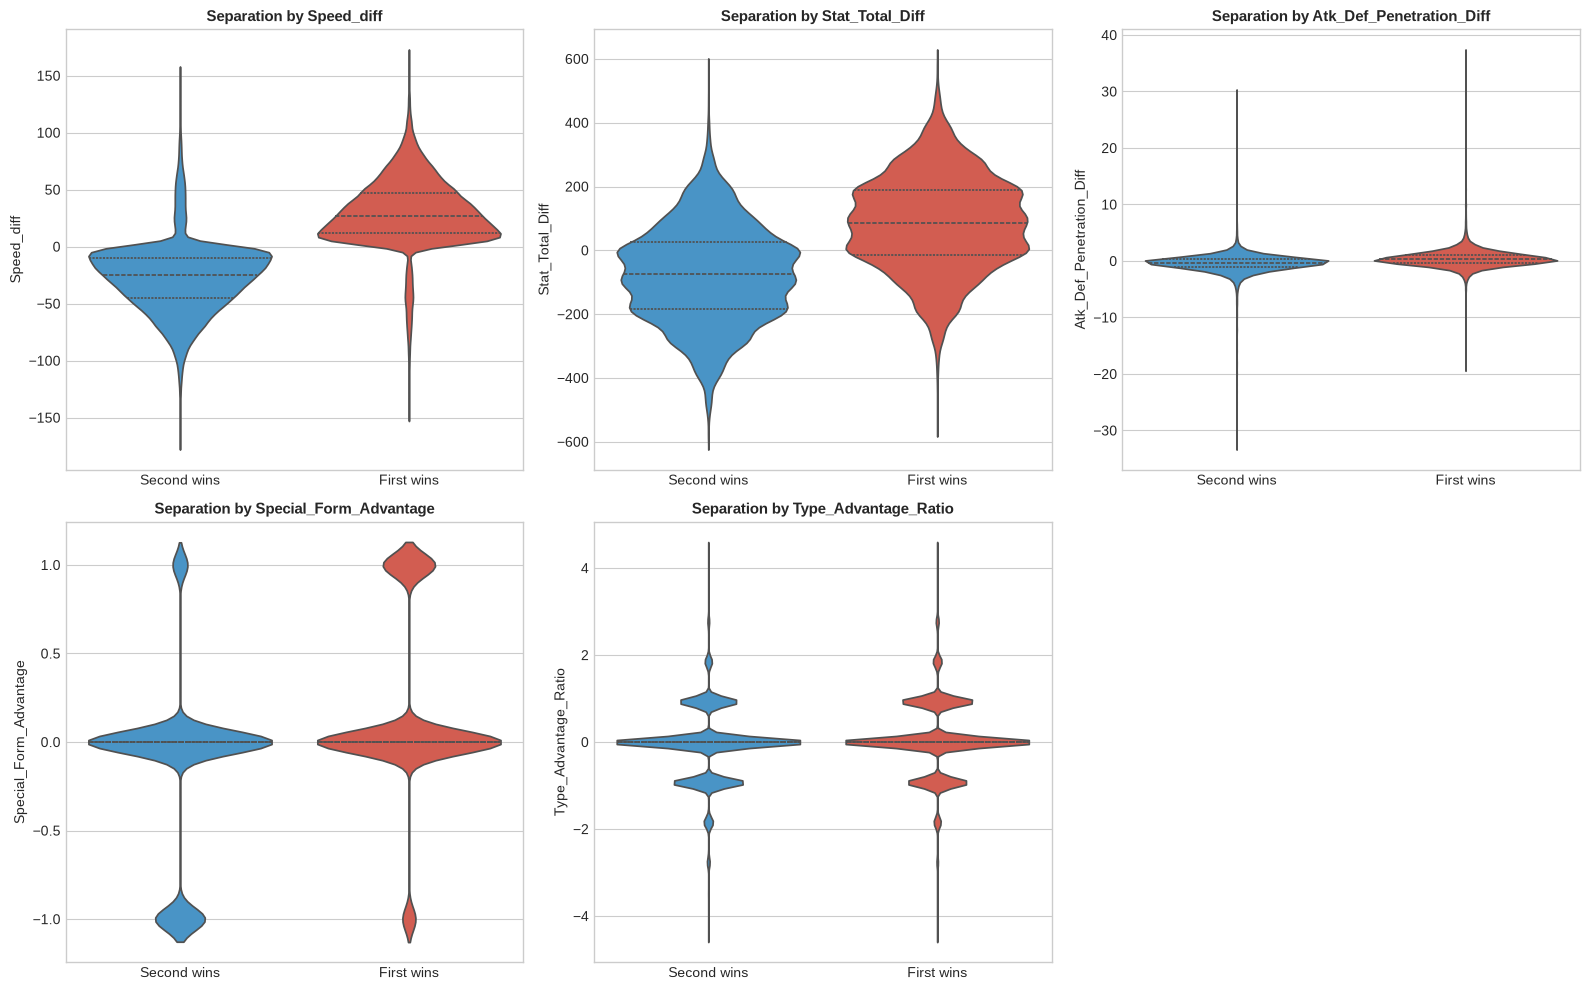

Result,First wins,Second wins
Speed_diff,29.567,-26.556
Stat_Total_Diff,84.904,-75.192
Atk_Def_Penetration_Diff,0.470,-0.413
Special_Form_Advantage,0.157,-0.140
Type_Advantage_Ratio,0.059,-0.060


In [22]:
# 10.2 Visual validation of all five features (bimodal separation)
df["Result"] = df["Target_First_Wins"].map({0: "Second wins", 1: "First wins"})
pal = {"Second wins": "#3498DB", "First wins": "#E74C3C"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(features):
    sns.violinplot(data=df, x="Result", y=feat, ax=axes[i], palette=pal, inner="quartile")
    axes[i].set_title(f"Separation by {feat}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

df[features].groupby(df["Result"]).mean().T.round(3)

### Feature-engineering findings

- `Speed_diff`, `Stat_Total_Diff` and `Atk_Def_Penetration_Diff` show strong bimodal separation
  between First-wins and Second-wins battles.
- `Special_Form_Advantage` confirms the gap: **75.9%** win rate with a special-form advantage vs
  **18.9%** with a disadvantage.
- `Type_Advantage_Ratio` provides a non-linear complement that is most useful near speed/stat
  parity.
- These five features replace the 12 raw base stats, eliminate the main multicollinearity, and are
  the recommended inputs for Assignment 2 models.


# 11. Conclusions, Limitations, and Modeling Roadmap (Requirement 4.11)

In this final section, we consolidate the empirical findings from the EDA, formally answer the
analytical guiding questions, quantify the empirical predictive ceiling, document dataset
limitations, establish data leakage prevention protocols, and define the strategic roadmap for
supervised modeling (Assignment 2).

### 11.1 Empirical Predictive Ceiling

Before modeling, we measure the **ceiling** that a simple, legitimate rule achieves. Because Speed
is a real predictor (not a leakage artifact), a rule that always picks the faster fighter — and the
second fighter on ties — quantifies how much of the outcome is already determined by one variable.

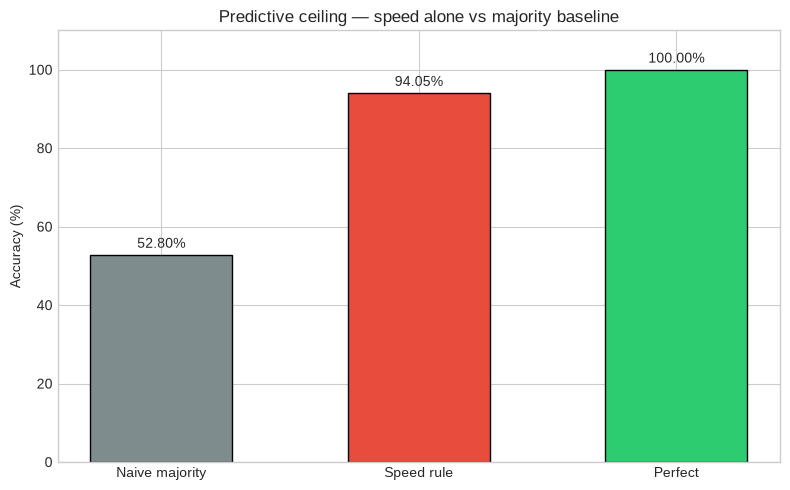

Majority baseline: 52.80%  |  Speed rule: 94.05%  |  Perfect: 100%


In [23]:
# 11.1 Predictive ceiling: speed rule vs baseline
rule_pred = (df["Speed_first"] > df["Speed_second"]).astype(int)
oracle_acc = (rule_pred == df["Target_First_Wins"]).mean() * 100

labels = ["Naive majority", "Speed rule", "Perfect"]
values = [baseline, oracle_acc, 100.0]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=["#7F8C8D", "#E74C3C", "#2ECC71"], width=0.55, edgecolor="black")
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.set(title="Predictive ceiling — speed alone vs majority baseline", ylabel="Accuracy (%)", ylim=(0, 110))
plt.tight_layout()
plt.show()
print(f"Majority baseline: {baseline:.2f}%  |  Speed rule: {oracle_acc:.2f}%  |  Perfect: 100%")

### 11.2 Executive Synthesis of EDA Findings

Across the preceding sections, we uncovered several foundational dynamics:

1. **Speed as the dominant decisive axis ($r = +0.678$):** Speed difference ($\Delta\text{Speed}$) is
   the single strongest linear predictor. Being faster than the opponent yields a **92.39% win rate**
   for the first fighter, whereas being slower collapses it to **4.60%**.
2. **Speed ties are decided by the SECOND fighter:** 94.0% (1,712 pairs) of orientation-swapped
   combats are deterministic. In the 6.0% (110 pairs) where the winner flips by position, **43.6%**
   exhibit exact speed ties, and in those ties the `Second_pokemon` wins **100%** of the time
   (1,328 battles). This corrects the earlier version of this notebook, which claimed the tie-break
   favored `First_pokemon`.
3. **Positional bias, not balance:** the target is 47.20% (First) vs 52.80% (Second), a systematic
   **+5.6 pp** bias explained by the tie rule.
4. **Special Forms Supremacy and Offensive Asymmetry:** Primal Reversions (**83.3%**), Alt. Combat
   Formes (**78.3%**), Legendaries (**76.4%**) and Mega Evolutions (**73.6%**) overpower standard
   Pokémon due to a massive base-stat gap (+100 to +350 pts). Attack difference has a higher linear
   correlation with victory ($r = +0.362$) than passive Defense ($r = +0.079$).
5. **Elemental Synergy in Parity Encounters:** Type advantage yields a **+10.7 pp** net win-rate
   increase (52.77% vs 42.05%), acting as the vital tie-breaker for speed-parity battles.
6. **Empirical ceiling:** a single speed rule already reaches **94.05%** accuracy, so models must
   focus capacity on the ~6% conflict zone to add value.

### 11.3 Quantitative Answers to Analytical Guiding Questions

1. **What variables exist, what nulls occur, and how are records structured?**
   *Answer:* 50,000 combats × 29 columns built from a single consolidated CSV. A single missing
   name was audited and imputed as **Primeape (#63)** by exact stat match; ~48% of `Type 2` nulls
   legitimately represent monotype species.

2. **How do evolutionary stages, Mega Evolutions, Primals, and Battle Formes influence outcomes?**
   *Answer:* Special forms (132 of the 784 species in battles, 16.8%) dominate standard Pokémon with
   **73.6%–83.3% win rates**. Mirror matches balance out near 50%, decided by speed and elemental
   matchups.

3. **Does entering as `First_pokemon` grant a significant advantage?**
   *Answer:* Not in general: 47.20% (First) vs 52.80% (Second) is a **positional bias** favoring
   the second fighter. However, in speed ties the `Second_pokemon` wins **100%** of the time.

4. **How strong is the correlation between higher Speed and winning?**
   *Answer:* Highest correlation in the dataset (**$r = +0.678$**). Higher speed secures victory in
   about 9 out of 10 battles (92.39% when the first fighter is faster).

5. **Are attribute differentials ($\Delta$) more predictive than absolute values?**
   *Answer:* Yes. Differentials ($\Delta\text{Speed}$, $\Delta\text{Total}$, $\Delta\text{Atk/Def}$)
   concentrate the signal and reduce multicollinearity compared with the 12 raw base stats.

6. **How do elemental type multipliers compare to base stats?**
   *Answer:* Type advantage adds **+10.7 pp** of win probability and resolves stat-parity battles.

7. **Do Legendary Pokémon consistently dominate, and how are generations distributed?**
   *Answer:* Legendaries (39 species, 5.0% of the battle pool) win **76.4%** against standard
   Pokémon. Generation is a catalogue attribute with no clear impact at battle level.


### 11.4 Identified Dataset Limitations

1. **Unobserved Movesets:** specific 4-move attack selections (*Thunderbolt*, *Flamethrower*,
   *Earthquake*) are unrecorded.
2. **Unobserved Abilities and Held Items:** passive abilities (*Levitate*, *Sturdy*) and combat
   items (*Choice Band*, *Focus Sash*) are absent.
3. **Irreducible randomness:** only 43.6% of the order-dependent (variable) pairs are explained by
   speed ties; the rest suggests an unobserved random component of the simulator.
4. **Approximate type chart:** the Gen-6 chart used here treats some matchups as neutral (default
   ×1); a complete chart may refine the type feature.
5. **Homogeneous Effort Values (EVs):** base stats represent Pokédex standard values under
   level-equalized conditions.
6. **Sample coverage:** the catalogue has 800 species but only **784** appear in the battles
   studied.


### 11.5 Strict Data Leakage Prevention Protocols

To ensure methodological rigor during the supervised training phase of Assignment 2, the following
mandatory protocols are established:

1. **Strict Exclusion of the `Winner` Column:**
   The raw `Winner` column (containing the winning Pokémon ID) must be dropped immediately after
   computing the binary target `Target_First_Wins`. Under no circumstances may it enter as a
   training predictor.

2. **Isolation of Relational Identifiers and Role of the `Name` Attribute:**
   - **Useful Feature Extraction:** Text columns `Name_first` and `Name_second` are indispensable
     during feature engineering to extract indicators for Mega Evolutions, Primal Reversions, and
     Alternative Battle Formes, as well as for imputing missing species like **Primeape (#63)**.
   - **Exclusion of Raw Text in the Model:** once the numerical and boolean derived features are
     extracted, raw text strings (`Name_first`, `Name_second`) and relational IDs (`First_pokemon`,
     `Second_pokemon`) are excluded from the final training matrix to prevent algorithms from
     overfitting on specific names, forcing them to learn the genuine physical combat mechanics.

3. **Cross-Validation Pipeline Isolation:**
   All feature scaling (StandardScaler or RobustScaler) and categorical encoding must be fit
   exclusively on training folds (*Train Folds*) and applied (*transform*) on validation/test folds
   (*Test Folds*).


### 11.6 Methodological Roadmap for Supervised Modeling (Assignment 2)

```mermaid
graph LR
    A["Consolidated Dataset with Engineered Features"] --> B["Stratified Split (80% Train / 20% Test)"]
    B --> C["Preprocessing Pipeline (RobustScaler + OneHot)"]
    C --> D["Candidate Model Training with 5-Fold CV"]
    D --> E["Comparative Evaluation vs Baseline (52.80%)"]
    E --> F["Optimal Model Selection (Target Accuracy > 94%)"]
```

1. **Validation Strategy:**
   - Stratified partition: 80% training (40,000 battles) and 20% test (10,000 battles).
   - Stratified 5-Fold Cross-Validation for hyperparameter tuning.

2. **Benchmarks to Beat:**
   - **Majority baseline:** **52.80%** accuracy.
   - **Speed rule (oracle):** **94.05%** accuracy (faster fighter wins; second wins on ties).

3. **Candidate Supervised Algorithms:**
   - **Linear Baseline Model:** *Logistic Regression* (to evaluate linear decision boundaries).
   - **Tree-Based Models:** *Decision Trees (CART)*, *Random Forest Classifier*, and
     *Gradient Boosting / XGBoost* (to capture non-linear type and speed interactions).
   - **Distance and Neural Models:** *K-Nearest Neighbors (KNN)* and *Multi-Layer Perceptron (MLP)*.

4. **Performance Metrics and Success Criteria:**
   - **Primary Metrics:** *Accuracy*, *Macro F1-Score*, *Confusion Matrix*, and *ROC-AUC*.
   - **Performance Goal:** surpass the **94.05%** speed-rule ceiling (with the engineered features
     resolving the conflict zone) — far above the 52.80% majority baseline.


> **Final Assignment 1 Conclusion (Exploratory Data Analysis):**
> - The EDA was executed across all sections on a single consolidated table
>   (`data/pokemon_combats_unified.csv`), with corrected simulator findings.
> - Victory is primarily governed by **Speed Differential ($r = +0.678$)**, **Total Power Gap
>   ($r = +0.470$)**, **Special Form Superiority (>73% win rate)**, and **Type Multipliers
>   (+10.7 pp)**.
> - The dataset is enriched with **5 master engineered features**, providing an optimal foundation
>   for Assignment 2 modeling, with an empirical ceiling of **94.05%**.
